# EXERCICE 7 : REGRESSION LINEAIRE MULTIPLE AVEC REGULARISATION + VALIDATION CROISEE


Inspire de http://scikit-learn.org/stable/auto_examples/linear_model/plot_lasso_and_elasticnet.html


In [1]:

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error


#### Génération de donnée synthétiques...

In [83]:

np.random.seed(31)

#... definition de n et p
n = 75

p =  200   #remarque : n<200 => necessite de selectionner des variables

#... simulation de X
X = np.random.randn(n, p) #remarque : on ne tient pas en compte les $beta_0$

#... generation du vecteur beta dans lequel seules 10 valeurs sont non-nulles
beta = 3 * np.random.randn(p)
inds = np.arange(p)
np.random.shuffle(inds)
beta[inds[10:]] = 0 

#... simulation de y 
y = np.dot(X, beta) + (2.0 * np.random.normal(size=n))


# REMARQUE IMPORTANTE : y ne dépend que des variables i pour lesquelles beta[i] est non-nul


# ... coupe en deux les donnees en donnees d'apprentissage et donnes test
thresh=n // 2
X_train = X[thresh:]
y_train = y[thresh:]
X_test = X[:thresh]
y_test = y[:thresh]


#### Régression linéaire avec régularisation Lasso ...


In [87]:

from sklearn.linear_model import Lasso

alpha = 0.5
lasso_regressor = Lasso(alpha=alpha)
lasso_regressor.fit(X_train, y_train)

y_pred_lasso = lasso_regressor.predict(X_test)
mse_score_lasso = mean_squared_error(y_test, y_pred_lasso)


####  Représentation du résultat


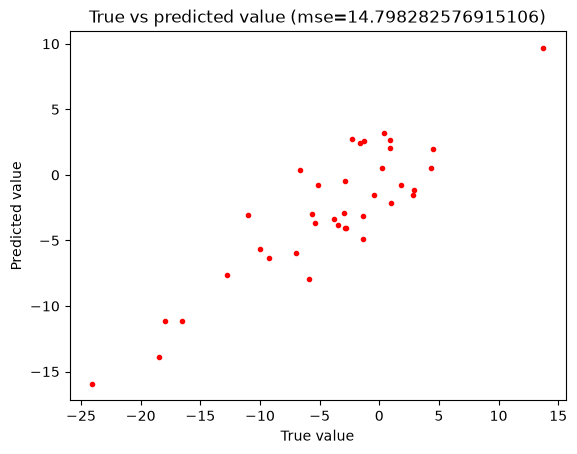

In [88]:
fig = plt.figure()
plt.plot(y_test, y_pred_lasso, 'r.')
plt.xlabel('True value')
plt.ylabel('Predicted value')

plt.title('True vs predicted value (mse='+str(mse_score_lasso)+')')
plt.show()



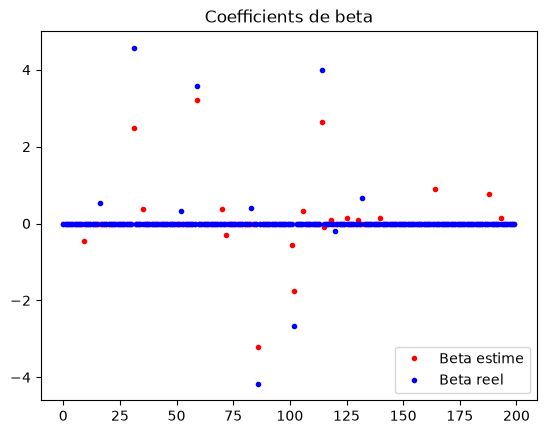

In [89]:

fig = plt.figure()
plt.plot(lasso_regressor.coef_, 'r.')
plt.plot(beta, 'b.')
plt.legend(('Beta estime', 'Beta reel'), loc='lower right')
plt.title('Coefficients de beta')
plt.show()



### <span style="color:blue">QUESTION 1</span> :

Jouez l'exemple avec  n=1000, n=100, n=75, n=50, n=25. Qu'en deduisez vous sur l'impact du nombre d'observations

### <span style="color:blue">REPONSE 1</span> :

...



### <span style="color:blue">QUESTION 2</span> :

On garde n=75. Utilisez la validation croisee de type K-folds (typiquement 8-Folds) pour trouver le meilleur coefficient *alpha* au sens de la MSE. Pour chaque *alpha* testé, on gardera comme score la MSE moyenne obtenue sur tous les *folds*.

Remarque : la recherche d'un bon coefficient *alpha* pourra d'abord se faire sur une échelle exponentielle assez large (ex: 0.001, 0.01, 0.1, ...) puis être raffinée sur une échelle plus fine.  

### <span style="color:blue">REPONSE 2</span> :

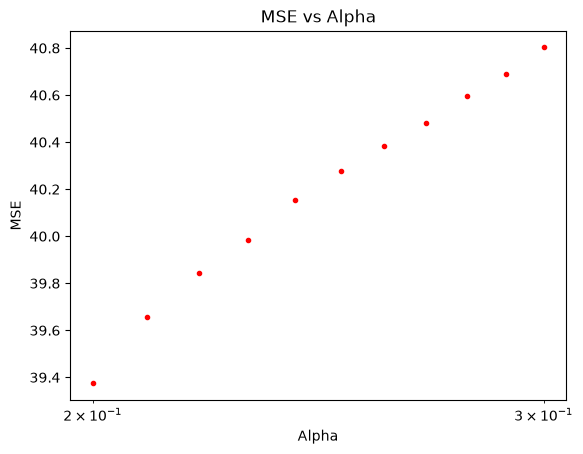

Best alpha for iteration 1: 0.2


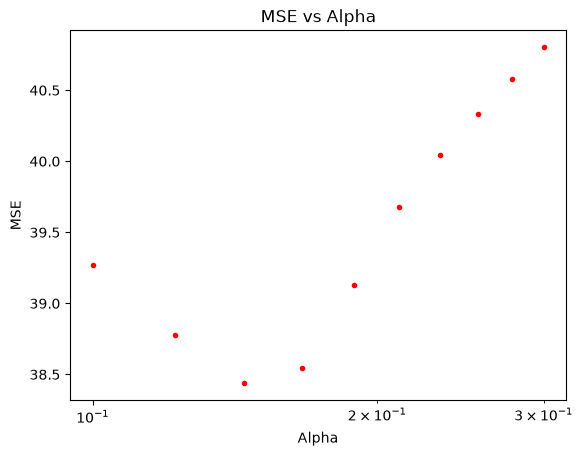

Best alpha for iteration 2: 0.14444444444444446


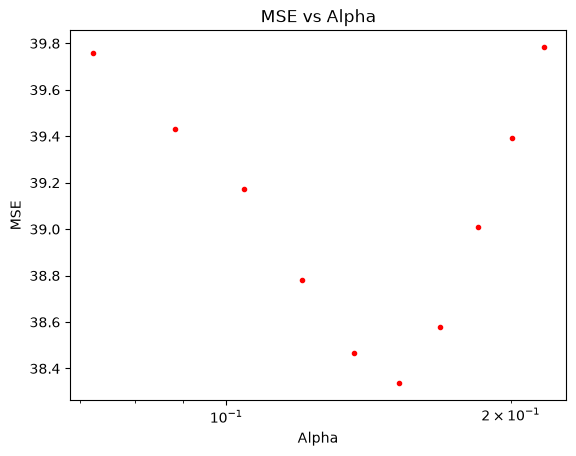

Best alpha for iteration 3: 0.15246913580246912


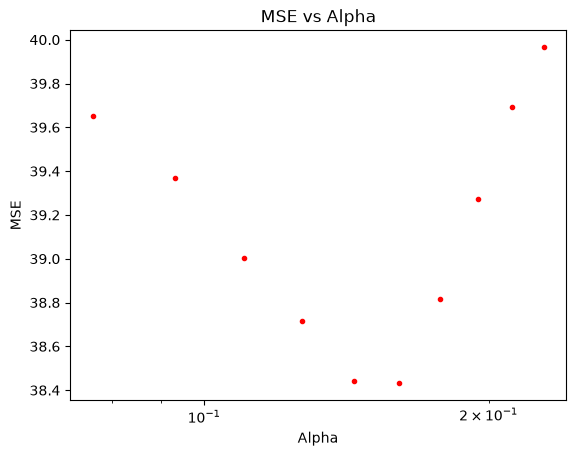

Best alpha for iteration 4: 0.16093964334705074


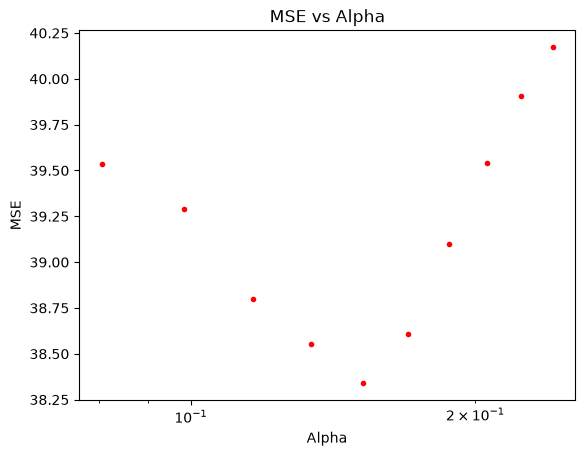

Best alpha for iteration 5: 0.15199855204999235


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",np.float64(0....9855204999235)
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [ ]:

from sklearn.model_selection import KFold

#...

def alpha_estimator(x,y,k,alpha_list):
    mse_list =[]
    kf = KFold(n_splits=k, shuffle=True, random_state=42)
    for alpha in alpha_list:
        mse_list_one_alpha = []
        lasso_regressor = Lasso(alpha=alpha)
        
        for train_index, test_index in kf.split(x):
            x_train, x_test = x[train_index], x[test_index]
            y_train, y_test = y[train_index], y[test_index]
            lasso_regressor.fit(x_train, y_train)
            y_pred_lasso = lasso_regressor.predict(x_test)
            mse_score_lasso = mean_squared_error(y_test, y_pred_lasso)
            mse_list_one_alpha.append(mse_score_lasso)
        mse_list.append(np.mean(mse_list_one_alpha))

    plt.figure()
    plt.semilogx(alpha_list, mse_list, 'r.')
    plt.xlabel('Alpha')
    plt.ylabel('MSE')
    plt.title('MSE vs Alpha')
    plt.show()
    return alpha_list[np.argmin(mse_list)], mse_list[np.argmin(mse_list)]




alpha_list = [0.2,0.21,0.22,0.23,0.24,0.25,0.26,0.27,0.28,0.29,0.3]
for i in range(5):
    best_alpha = alpha_estimator(X_train, y_train,8 , alpha_list)[0]
    print(f"Best alpha for iteration {i+1}: {best_alpha}")
    alpha_list = list(np.linspace(best_alpha*0.5, best_alpha*1.5, 10))


lasso_regressor = Lasso(alpha=best_alpha
                        )
lasso_regressor.fit(X_train, y_train)


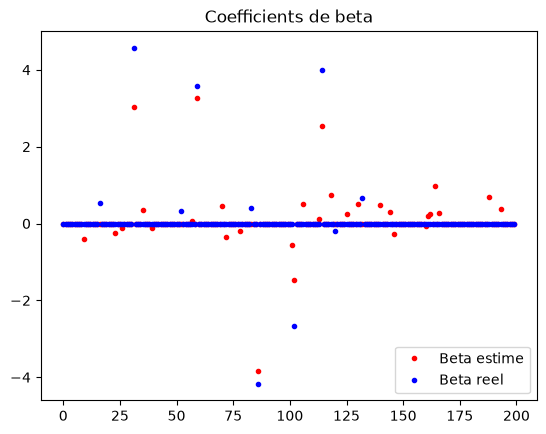

In [57]:
#représentation des coefficients estimés (lasso_regressor.coef_) et de ceux
#avec lesquels les données ont été simulées (beta)

fig = plt.figure()
plt.plot(lasso_regressor.coef_, 'r.')
plt.plot(beta, 'b.')
plt.legend(('Beta estime', 'Beta reel'), loc='lower right')
plt.title('Coefficients de beta')
plt.show()


### <span style="color:blue">QUESTION 3</span> :

De manère alternative, codez et testez maintenant une sélection de type *forward* avec un critère de sélection *BIC*.

Comparez les résultats avec ceux obtenus à l'aide de la pénalisation LASSO.

### <span style="color:blue">REPONSE 3</span> :


In [90]:


from sklearn.linear_model import LinearRegression


def beta_selection_forward_bic(x,y):
    n =x.shape[0]


    q=1
    idx_list = []
    bic_list =[]
    current_bic = np.inf
    #Première itération
    for i in range(x.shape[1]):
        lr = LinearRegression()
        lr.fit(x[:, i].reshape(-1, 1), y)
        bic_coef = n * np.log(mean_squared_error(y, lr.predict(x[:, i].reshape(-1, 1)))) + (q+1) * np.log(n)
        if bic_coef < current_bic:
            current_bic = bic_coef
            idx = i
    idx_list.append(idx)
    bic_list.append(current_bic)



    while True:
        q+=1
        best_bic = np.inf
        list_idx_to_explore = [i for i in range(x.shape[1]) if i not in idx_list]
        for i in list_idx_to_explore:
            lr = LinearRegression()
            lr.fit(x[:, idx_list + [i]], y)
            bic_coef = n * np.log(mean_squared_error(y, lr.predict(x[:, idx_list + [i]]))) + (q+1) * np.log(n)
            if bic_coef < best_bic:
                best_bic = bic_coef
                best_idx = i

        if best_bic < current_bic:
            current_bic = best_bic
            idx_list.append(best_idx)
            bic_list.append(current_bic)
        else:
            break
    return idx_list, bic_list


    
# print("Selection de variables par BIC")
# print("Variables selectionnees : ", beta_selection_forward_bic(X_train, y_train)[0])


#...



Text(0.5, 1.0, 'Coefficients de beta')

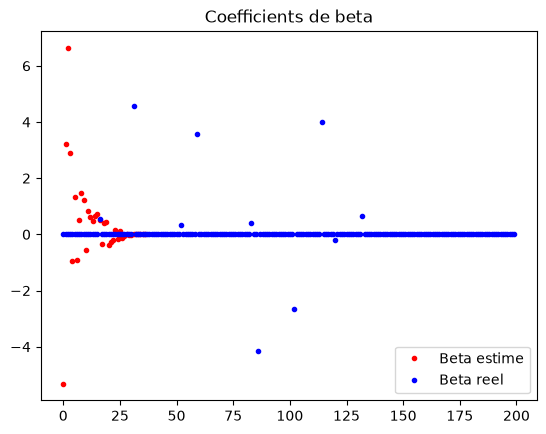

In [81]:
lr = LinearRegression()
idx_list, bic_list = beta_selection_forward_bic(X_train, y_train)
lr.fit(X_train[:, idx_list], y_train)
y_pred_lr = lr.predict(X_test[:, idx_list])


plt.figure()
plt.plot(lr.coef_, 'r.')
plt.plot(beta, 'b.')
plt.legend(('Beta estime', 'Beta reel'), loc='lower right')
plt.title('Coefficients de beta')